# Entrenamiento Especializado por Método de Manipulación

Este notebook entrena un modelo (EfficientNet-B4) exclusivamente sobre imágenes reales y un solo tipo de deepfake a la vez. 
Se debe ejecutar 5 veces, cambiando la variable `TARGET_METHOD` para generar los modelos especializados que se usarán en el experimento de generalización cruzada.

In [1]:
from pathlib import Path
import torch
import torch.nn as nn

from src.config import make_config, set_seed, PROJECT_ROOT
from src.data import build_frame_dataframe, filter_by_method, make_loaders
from src.models import build_model, build_optimizer
from src.engine import train_model

TARGET_METHOD = 'FaceShifter'  # 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter'

CONFIG = make_config(
    MODEL_NAME = 'xception',
    OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'cross_gen_xception',
    TARGET     = TARGET_METHOD,
    BATCH_SIZE = 64,
    EPOCHS     = 10,
    PATIENCE   = 4,
)
set_seed(CONFIG['SEED'])

print(f"PREPARANDO ENTRENAMIENTO PARA: {TARGET_METHOD}")
print(f"Los resultados se guardarán en: {CONFIG['OUTPUT_DIR']}\n")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PREPARANDO ENTRENAMIENTO PARA: FaceShifter
Los resultados se guardarán en: /home/mariasarachaga/TPF-VA/outputs/cross_gen_xception



In [2]:
df_all = build_frame_dataframe(CONFIG['DATA_DIR'], splits=['train', 'val'])
df = filter_by_method(df_all, TARGET_METHOD)

print(f'Frames para {TARGET_METHOD} (real + {TARGET_METHOD}): {len(df):,}')
print(df.groupby(['split', 'label']).size().unstack(fill_value=0))

Frames para FaceShifter (real + FaceShifter): 17,200
label     0     1
split            
train  7200  7200
val    1400  1400


In [3]:
train_loader, val_loader, _ = make_loaders(df, CONFIG)

Train: 14,400 | Val: 2,800


In [4]:
model = build_model(CONFIG['MODEL_NAME'], CONFIG['DEVICE'], dropout=CONFIG['DROPOUT'])
optimizer = build_optimizer(model, CONFIG['LR'], CONFIG['LR_HEAD'], CONFIG['WEIGHT_DECAY'])
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6
)

/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


xception — parámetros entrenables: 20,809,001


In [5]:
print(f'Entrenando modelo especializado en {TARGET_METHOD}')
df_history = train_model(
    model, TARGET_METHOD, train_loader, val_loader,
    optimizer, criterion, scheduler, CONFIG
)
df_history.to_csv(CONFIG['OUTPUT_DIR'] / f"history_{CONFIG['TARGET']}.csv", index=False)
print(f"\nHistorial guardado en CSV para {CONFIG['TARGET']}.")

Entrenando modelo especializado en FaceShifter


Epoch 01/10 | train_loss=0.5230 train_acc=0.6907 | val_loss=0.5935 val_acc=0.7529 val_auc=0.8880  ✓ checkpoint guardado (AUC=0.8880)


Epoch 02/10 | train_loss=0.3029 train_acc=0.8321 | val_loss=0.4752 val_acc=0.8325 val_auc=0.9321  ✓ checkpoint guardado (AUC=0.9321)


Epoch 03/10 | train_loss=0.2307 train_acc=0.8717 | val_loss=0.3457 val_acc=0.8779 val_auc=0.9532  ✓ checkpoint guardado (AUC=0.9532)


Epoch 04/10 | train_loss=0.1991 train_acc=0.8867 | val_loss=0.3914 val_acc=0.8850 val_auc=0.9568  ✓ checkpoint guardado (AUC=0.9568)


...

Epoch 06/10 | train_loss=0.1628 train_acc=0.9057 | val_loss=0.4198 val_acc=0.8925 val_auc=0.9636  ✓ checkpoint guardado (AUC=0.9636)


Epoch 07/10 | train_loss=0.1541 train_acc=0.9129 | val_loss=0.5458 val_acc=0.8775 val_auc=0.9578  (sin mejora 1/4)


Epoch 08/10 | train_loss=0.1465 train_acc=0.9162 | val_loss=0.4808 val_acc=0.8857 val_auc=0.9616  (sin mejora 2/4)


Epoch 09/10 | train_loss=0.1407 train_acc=0.9194 | val_loss=0.4804 val_acc=0.8857 val_auc=0.9630  (sin mejora 3/4)


Epoch 10/10 | train_loss=0.1385 train_acc=0.9221 | val_loss=0.4606 val_acc=0.8921 val_auc=0.9630  (sin mejora 4/4)

Early stopping en época 10.

Historial guardado en CSV para FaceShifter.


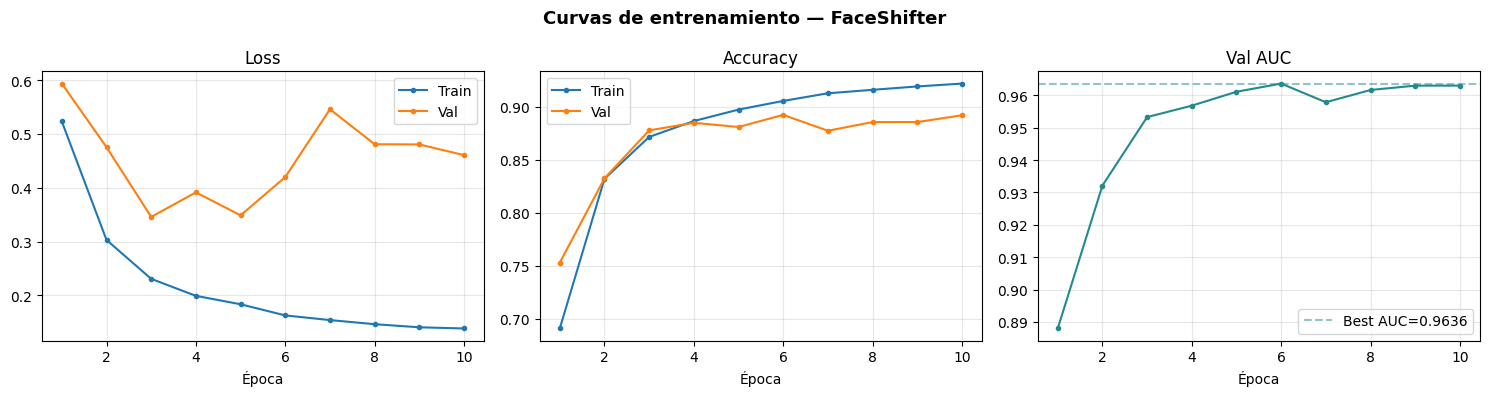

In [6]:
from src.viz import plot_history
plot_history(df_history, TARGET_METHOD, CONFIG['OUTPUT_DIR'])